# Final Project Module 3

In [41]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_diabetes
from pandas.plotting import scatter_matrix
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import learning_curve, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
%matplotlib widget


In [42]:
data = load_diabetes()
X, y = data.data, data.target

df = pd.DataFrame(X, columns = data.feature_names)
df["target"] = y

display(df)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


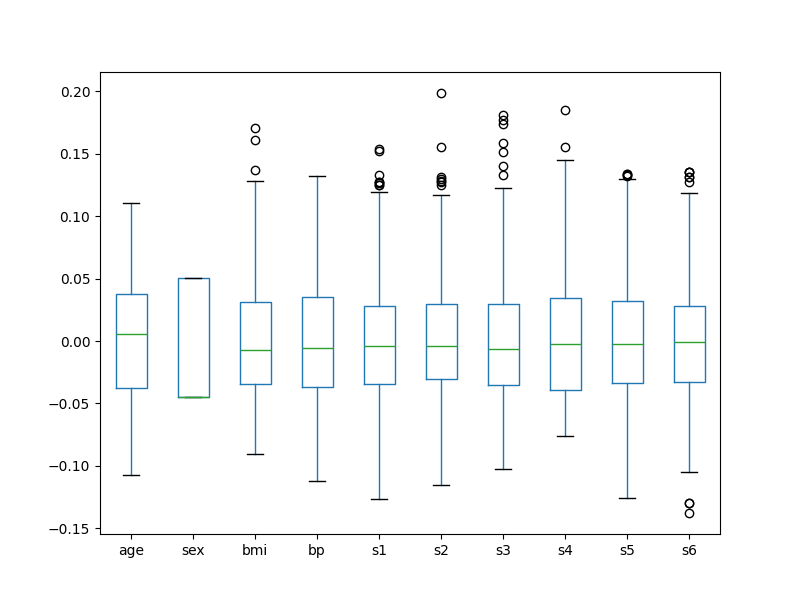

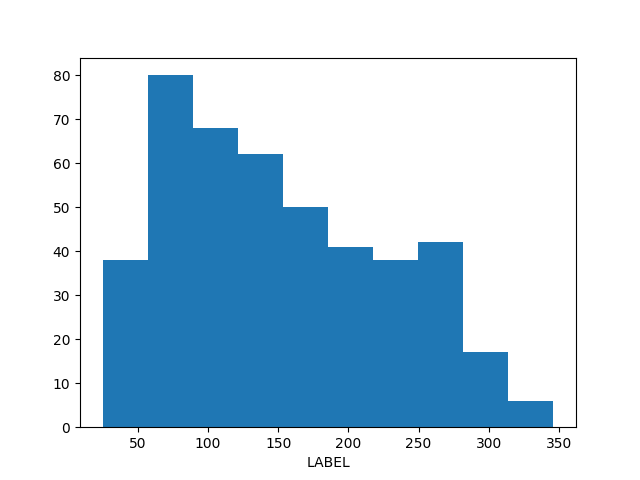

In [43]:
df.drop(columns=["target"]).boxplot(figsize = (8,6), grid = False)
plt.show()

plt.figure()
plt.hist(df["target"])
plt.xlabel("LABEL")
plt.show()

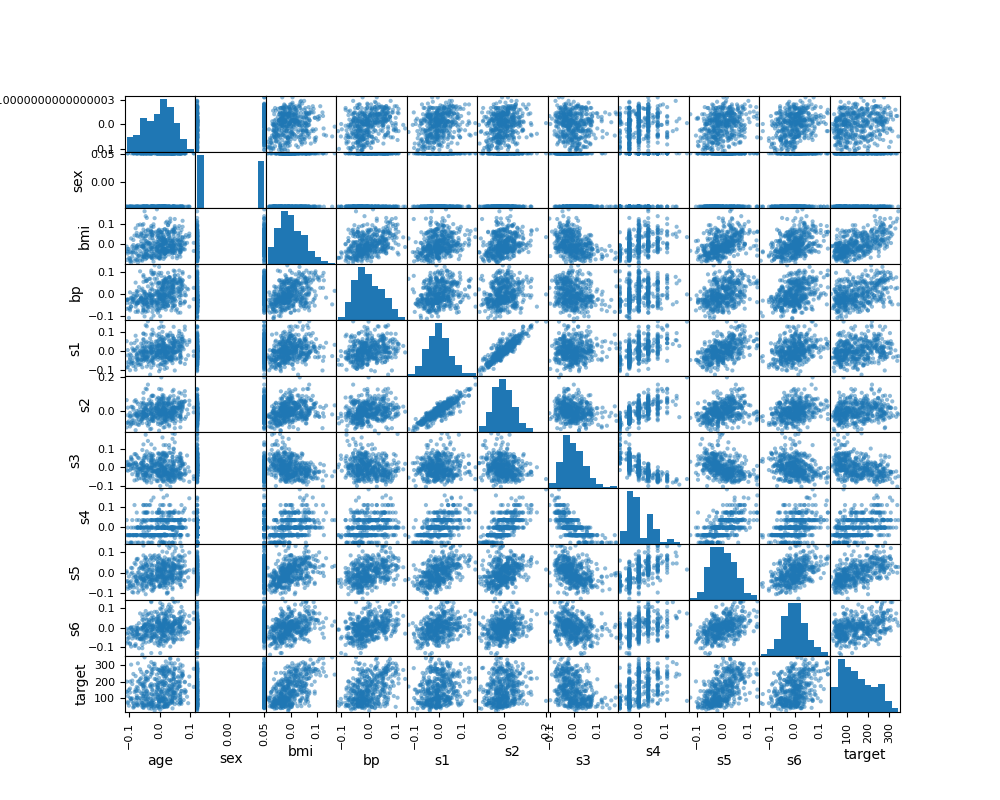

In [44]:
scatter_matrix(df, figsize=(10,8))
plt.show()

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    shuffle = True, 
    random_state=42, 
    test_size=0.2
)


In [46]:
# Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Parte 2: Confronto e Selezione Iniziale dei Modelli

In [47]:
models = [
    ("SVM", SVR(gamma="auto")), 
    ("KNN", KNeighborsRegressor()), 
    ("DECISION TREE REGRESSOR", DecisionTreeRegressor()), 
    ("LINEAR REGRESSION", LinearRegression()), 
    ("LINEAR RIDGE", Ridge()),
    ("LINEAR LASSO", Lasso())
]


In [48]:
names = []
results = []

K = 10
for name, model in models: 
    kfold = KFold(n_splits = K, shuffle = True, random_state=42)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv = kfold, scoring = "neg_mean_squared_error")
    
    names.append(name)
    results.append(cv_results)
    print(f"{name}\n \tNMSE: {cv_results.mean():.4f}\n \tSTD: {cv_results.std():.4f}\n \tMAE : {np.sqrt(-cv_results.mean()):.4f}")

SVM
 	NMSE: -5223.1426
 	STD: 1229.7158
 	MAE : 72.2713
KNN
 	NMSE: -3902.6225
 	STD: 665.5482
 	MAE : 62.4710
DECISION TREE REGRESSOR
 	NMSE: -7078.9510
 	STD: 1515.0643
 	MAE : 84.1365
LINEAR REGRESSION
 	NMSE: -3067.3095
 	STD: 548.7667
 	MAE : 55.3833
LINEAR RIDGE
 	NMSE: -3065.8272
 	STD: 552.1398
 	MAE : 55.3699
LINEAR LASSO
 	NMSE: -3081.7230
 	STD: 552.6778
 	MAE : 55.5133


Parte 3: Hyperparameters Tuning

Si sceglie il modello LINEAR LASSO (buone performance con almeno un hyperparameter per effettuare il tuning)

In [49]:
model = Lasso()
model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)

# Applica Grid Search per trovare un iperparametro ideale. 
param_grid = {
    "alpha" : np.logspace(-2,2,5)
}

grid = GridSearchCV(Lasso(), param_grid=param_grid, cv = 5, scoring = "neg_mean_squared_error")
grid.fit(X_train_scaled, y_train)

best_lasso = grid.best_estimator_
y_pred_best = best_lasso.predict(X_test_scaled)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

if mse_best < -results[5].mean(): 
    string = f"MIGLIORAMENTO OTTENUTO!\n"
else: 
    string = "PRESTAZIONI MODELLO PEGGIORATE DOPO GRID SEARCH!"
print(string)
print(f"MIGLIOR PARAMETRO ALPHA: {grid.best_params_}")
print(f"MSE (base): {-results[5].mean():.4f}")
print(f"MSE (best): {mse_best:.4f}")
print(f"R2 SCORE (best): {r2_best:.4f}")



MIGLIORAMENTO OTTENUTO!

MIGLIOR PARAMETRO ALPHA: {'alpha': np.float64(1.0)}
MSE (base): 3081.7230
MSE (best): 2824.5681
R2 SCORE (best): 0.4669


Part 4: Analisi delle Performance

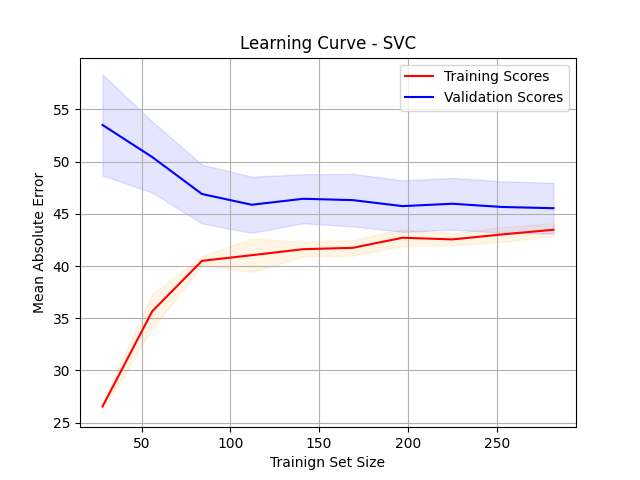

In [50]:
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    model, 
    X_train_scaled, 
    y_train, 
    cv = 5, 
    n_jobs = 1, 
    scoring= "neg_mean_absolute_error", 
    train_sizes= np.linspace(0.1,1.0,10)
)

train_mean = np.mean(train_scores, axis = 1)
train_std = np.std(train_scores, axis = 1)
val_mean = np.mean(val_scores, axis = 1)
val_std = np.std(val_scores, axis =1)

plt.figure()
plt.plot(train_sizes, -train_mean, color = "red", label = "Training Scores")
plt.fill_between(train_sizes, -train_mean - train_std, -train_mean + train_std, alpha = 0.1, color = "orange")

plt.plot(train_sizes, -val_mean, color = "blue", label = "Validation Scores")
plt.fill_between(train_sizes, -val_mean - val_std, -val_mean + val_std, alpha = 0.1, color = "blue")

plt.xlabel("Trainign Set Size")
plt.ylabel("Mean Absolute Error")
plt.title("Learning Curve - SVC")
plt.legend()
plt.grid()
plt.show()

Le due curve presentano:
1. Valori bassi di errore (circa 10% del massimo della label y)
2. Convergenza a bassi valori di errore per training set size alti

Questi segnali indicano assenza di overfitting e underfitting, con comportamento ideale del modello. 

Parte 5: Visualizzazione con Data Reduction tramite PCA

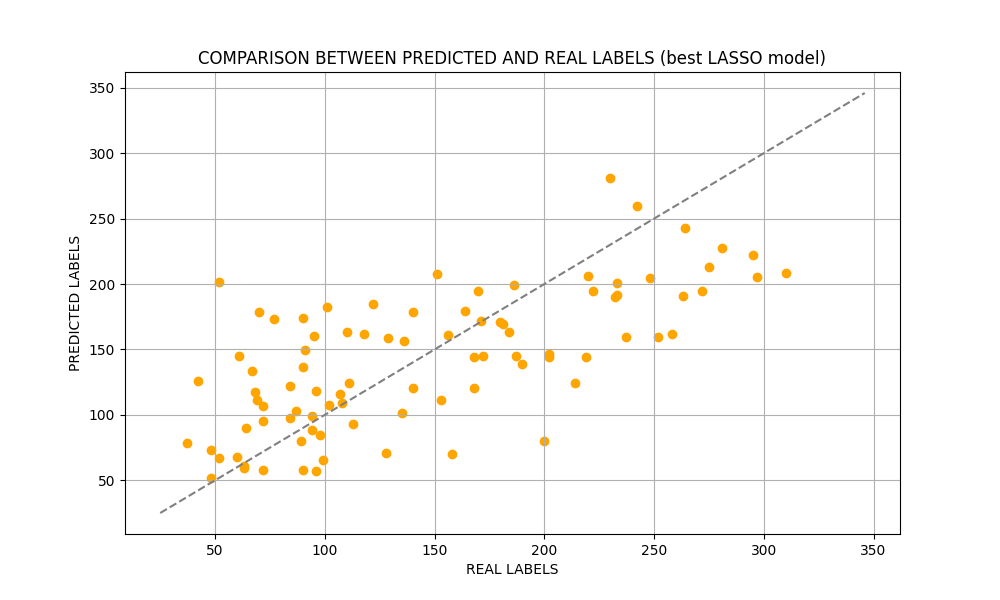

In [51]:

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_best, color = "orange")
plt.plot([y.min(), y.max()],[y.min(), y.max()], color = "grey", linestyle = "--")
plt.grid(visible=True)
plt.title("COMPARISON BETWEEN PREDICTED AND REAL LABELS (best LASSO model)")
plt.xlabel("REAL LABELS")
plt.ylabel("PREDICTED LABELS")
plt.show()

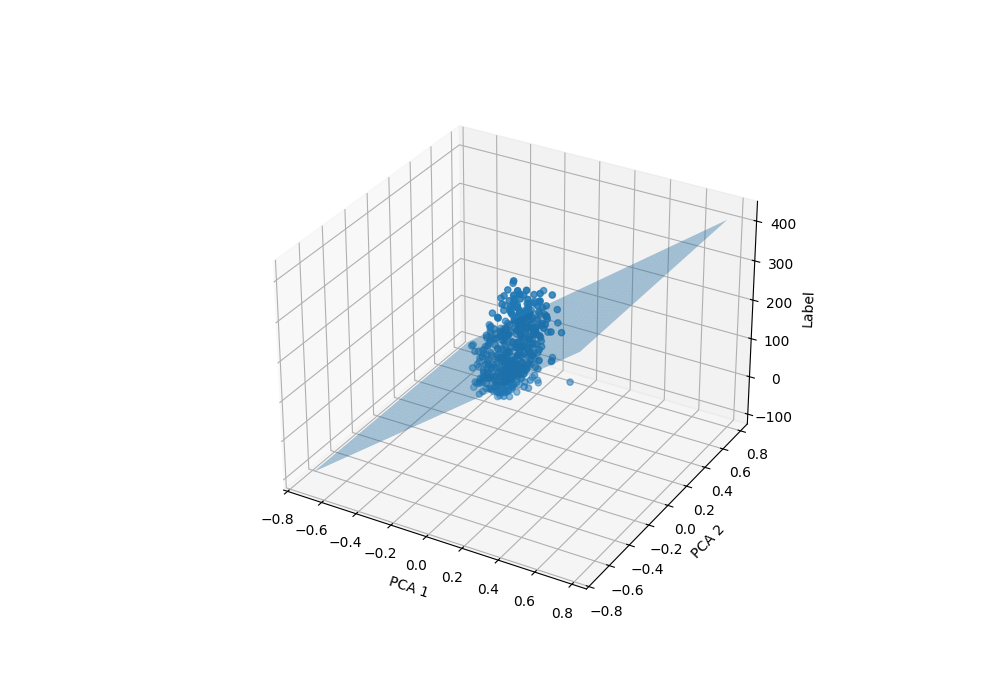

In [54]:
# Visualizzazione del Piano di Regressione nello Spazio delle Feature
from mpl_toolkits.mplot3d import Axes3D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
lasso_pca = Lasso(alpha=1.0)

X_pca = np.column_stack((X_pca[:,0], X_pca[:,1]))

pca1_min, pca1_max = X_pca[:,0].min() - 0.5, X_pca[:,0].max() + 0.5
pca2_min, pca2_max = X_pca[:,0].min() - 0.5, X_pca[:,0].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(pca1_min, pca1_max, 100),
    np.linspace(pca2_min, pca2_max, 100)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
lasso_pca.fit(X_pca,y)
zz = lasso_pca.predict(grid_points)
zz = zz.reshape(xx.shape)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], y)
ax.plot_surface(xx, yy, zz, alpha=0.4)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("Label")
plt.show()